# Spatial Join: 311 Tickets → Census Tract → SVI Features

**Goal**: Map each 311 ticket's lat/lon to its Census Tract, then attach SVI socioeconomic features.

This replaces the previous zip_code-level join, giving us tract-level granularity (~4,000 residents per tract vs ~30,000 per zip code) to reduce ecological fallacy risk.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path

BASE = Path("/Users/rayxu/CS506_Final_Project/problemstic")

# Load 311 data
df = pd.read_parquet(BASE / "boston_311_2020_2026.parquet")
print(f"311 records: {len(df):,}")
print(f"Lat range: {df['latitude'].min():.4f} - {df['latitude'].max():.4f}")
print(f"Lon range: {df['longitude'].min():.4f} - {df['longitude'].max():.4f}")

311 records: 1,694,448
Lat range: -71.1358 - 42.3990
Lon range: -71.1907 - 42.3585


In [2]:
# Load Census Tract shapefile (MA)
tracts = gpd.read_file(BASE / "data/shapefiles/tl_2022_25_tract.shp")
print(f"Census Tracts: {len(tracts)}, CRS: {tracts.crs}")

# Load SVI features
svi = pd.read_csv(BASE / "data/svi_2022_ma_tract.csv")
svi["FIPS"] = svi["FIPS"].astype(str).str.zfill(11)
print(f"SVI records: {len(svi)}")
print(f"SVI features: {[c for c in svi.columns if c.startswith('EP_')]}")

Census Tracts: 1620, CRS: EPSG:4269
SVI records: 1620
SVI features: ['EP_POV150', 'EP_UNEMP', 'EP_NOHSDP', 'EP_NOVEH', 'EP_LIMENG', 'EP_MINRTY']


In [3]:
# Merge SVI features into tract polygons
tracts = tracts.merge(svi, left_on="GEOID", right_on="FIPS", how="left")
print(f"Tracts with SVI: {tracts['EP_POV150'].notna().sum()} / {len(tracts)}")

# Convert 311 points to GeoDataFrame with same CRS as tracts
gdf_311 = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"  # WGS84
)

# Reproject to match tract CRS (EPSG:4269 NAD83 — nearly identical but technically different)
gdf_311 = gdf_311.to_crs(tracts.crs)
print(f"311 GeoDataFrame: {len(gdf_311):,} points, CRS: {gdf_311.crs}")

Tracts with SVI: 1598 / 1620


311 GeoDataFrame: 1,694,448 points, CRS: EPSG:4269


## Point-in-Polygon Spatial Join

For each 311 ticket, find which Census Tract polygon contains its lat/lon point. This is a `sjoin` with `predicate="within"`. Points outside all MA tracts (e.g., data errors) will be dropped.

In [4]:
%%time
# Spatial join: point-in-polygon
svi_cols = ["GEOID"] + [c for c in tracts.columns if c.startswith("EP_")]
tracts_slim = tracts[svi_cols + ["geometry"]]

joined = gpd.sjoin(gdf_311, tracts_slim, how="left", predicate="within")

# Check results
matched = joined["GEOID"].notna().sum()
total = len(joined)
print(f"Matched to tract: {matched:,} / {total:,} ({matched/total:.1%})")
print(f"Unmatched (outside MA tracts): {total - matched:,}")
print(f"\nUnique tracts with tickets: {joined['GEOID'].nunique()}")

Matched to tract: 1,694,444 / 1,694,448 (100.0%)
Unmatched (outside MA tracts): 4

Unique tracts with tickets: 327
CPU times: user 2.4 s, sys: 341 ms, total: 2.75 s
Wall time: 2.86 s


In [5]:
# Drop unmatched points and clean up
df_final = joined.drop(columns=["geometry", "index_right"]).copy()
df_final = df_final[df_final["GEOID"].notna()].reset_index(drop=True)

# Add target variables (same logic as march_checkin)
current_time = pd.Timestamp("2026-04-08", tz="UTC")
df_final["open_dt"] = pd.to_datetime(df_final["open_dt"], utc=True)
df_final["closed_dt"] = pd.to_datetime(df_final["closed_dt"], utc=True)

df_final["is_censored"] = np.where(df_final["case_status"] == "Open", 1, 0)
df_final["resolution_time_days"] = np.where(
    df_final["case_status"] == "Closed",
    (df_final["closed_dt"] - df_final["open_dt"]).dt.total_seconds() / 86400,
    (current_time - df_final["open_dt"]).dt.total_seconds() / 86400
)
df_final = df_final[df_final["resolution_time_days"] >= 0]
df_final["is_overdue"] = np.where(df_final["resolution_time_days"] > 30, 1, 0)

print(f"Final dataset: {len(df_final):,} records")
print(f"Overdue rate: {df_final['is_overdue'].mean():.2%}")
print(f"Unique tracts: {df_final['GEOID'].nunique()}")
print(f"\nSVI feature coverage:")
for col in [c for c in df_final.columns if c.startswith("EP_")]:
    pct = df_final[col].notna().mean()
    print(f"  {col}: {pct:.1%} non-null")

Final dataset: 1,605,853 records
Overdue rate: 18.42%
Unique tracts: 327

SVI feature coverage:
  EP_POV150: 99.3% non-null
  EP_UNEMP: 99.3% non-null
  EP_NOHSDP: 99.4% non-null
  EP_NOVEH: 99.0% non-null
  EP_LIMENG: 99.4% non-null
  EP_MINRTY: 99.4% non-null


In [6]:
# Save the joined dataset
output_path = BASE / "boston_311_with_svi.parquet"
df_final.to_parquet(output_path, index=False)

import os
size_mb = os.path.getsize(output_path) / 1e6
print(f"Saved to {output_path}")
print(f"File size: {size_mb:.1f} MB")
print(f"\nColumns: {list(df_final.columns)}")

Saved to /Users/rayxu/CS506_Final_Project/problemstic/boston_311_with_svi.parquet
File size: 197.1 MB

Columns: ['case_enquiry_id', 'open_dt', 'closed_dt', 'sla_target_dt', 'on_time', 'case_status', 'closure_reason', 'case_title', 'subject', 'reason', 'type', 'queue', 'department', 'source', 'location', 'location_street_name', 'location_zipcode', 'neighborhood', 'ward', 'precinct', 'fire_district', 'pwd_district', 'city_council_district', 'police_district', 'latitude', 'longitude', 'data_year', 'resolution_days', 'GEOID', 'EP_POV150', 'EP_UNEMP', 'EP_NOHSDP', 'EP_NOVEH', 'EP_LIMENG', 'EP_MINRTY', 'is_censored', 'resolution_time_days', 'is_overdue']


## Quick Sanity Check: SVI Distribution Across Tickets

Verify that the spatial join produced meaningful variation in SVI features — if all tickets land in the same few tracts, we won't have enough variance for regression.

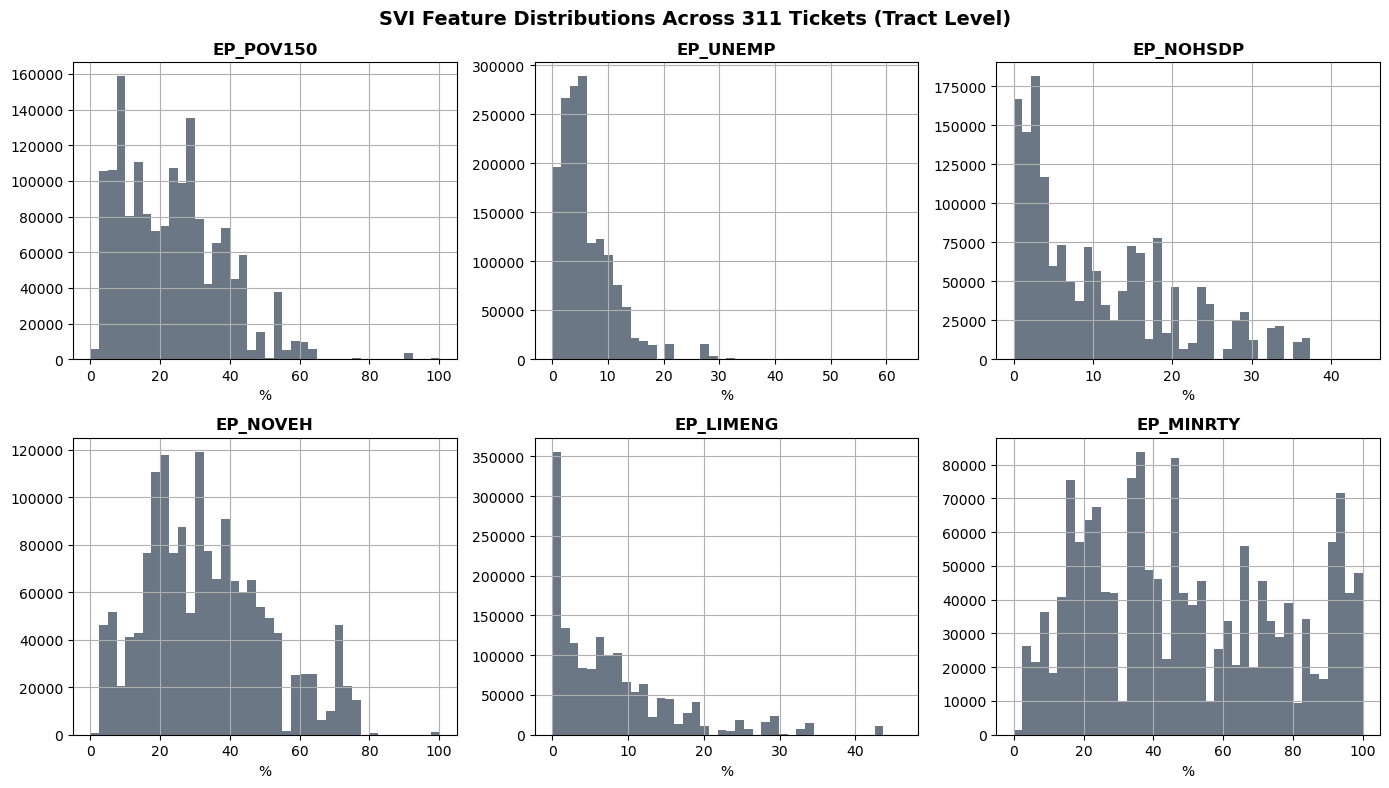

In [7]:
import matplotlib.pyplot as plt

ep_cols = [c for c in df_final.columns if c.startswith("EP_")]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, ep_cols):
    df_final[col].dropna().hist(bins=40, ax=ax, color="#2c3e50", alpha=0.7)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("%")
fig.suptitle("SVI Feature Distributions Across 311 Tickets (Tract Level)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig(str(BASE / "svi_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()